# Ocean colour Climatology and Bathymetry
## Core 3 CS- Saldanha Bay Coastal Region
This notebook forms a part of the SAMS Core 3 Capstone Group assignment.
The objective is to visualise and analyse climatological satellite-derived
chlorophyll concentrations together with bathymetric information for a
coastal region of interest.
**Region:** Saldanha Bay and adjacent West Coast of South Africa





In [1]:
# Import core scientific Python libraries
import xarray as xr               # For working with NetCDF data
import numpy as np                # Numerical operations
import matplotlib.pyplot as plt   # Plotting
import cartopy.crs as ccrs        # Map projections
import cartopy.feature as cfeature
import cmocean                    # Oceanographically appropriate colormaps

## Bathymetry (GMRT)

Bathymetry describes the depth and shape of the seafloor and provides
important physical context for interpreting chlorophyll distributions.
In this section, bathymetric data from the Global Multi-Resolution
Topography (GMRT) dataset are loaded, inspected, and visualised for the
Saldanha Bay region.

In [2]:
import os

os.listdir("Capstone_Assesment")

['ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc',
 'GMRTv4_4_1_20260512topo.grd']

In [3]:
# Load GMRT bathymetry data from a GMT grid (.grd) file.
# Although the file extension is .grd, it follows NetCDF conventions
# and can be read directly using xarray.

bathy_path = "Capstone_Assesment/GMRTv4_4_1_20260512topo.grd"

bathy = xr.open_dataset(bathy_path)

bathy


<xarray.Dataset> Size: 237MB
Dimensions:    (side: 2, xysize: 29660832)
Dimensions without coordinates: side, xysize
Data variables:
    x_range    (side) float64 16B ...
    y_range    (side) float64 16B ...
    z_range    (side) float64 16B ...
    spacing    (side) float64 16B ...
    dimension  (side) int32 8B ...
    z          (xysize) float64 237MB ...
Attributes:
    title:    GMRT Grid
    source:   \n\tProjection: Cylindrical Equidistant\n\tCreated with GMRT Ma...

### Bathymetry Dataset Description

The bathymetry data were obtained from the Global Multi-Resolution
Topography (GMRT) synthesis using the GMRT MapTool.

The dataset is provided as a GMT grid (`.grd`) file. Although this
differs from the standard `.nc` extension, the file follows NetCDF
conventions and is fully compatible with xarray.

The primary variable represents seafloor elevation, where negative
values indicate ocean depth.

In [4]:
# Identify the available data variables in the bathymetry dataset

list(bathy.data_vars)


['x_range', 'y_range', 'z_range', 'spacing', 'dimension', 'z']

In [5]:
# Extract grid dimensions (number of points in x and y)
nx, ny = bathy.dimension.values
nx, ny


(np.int32(4552), np.int32(6516))

In [6]:
# Reshape the bathymetry data into a 2D grid
z = bathy.z.values.reshape((ny, nx))

z.shape


(6516, 4552)

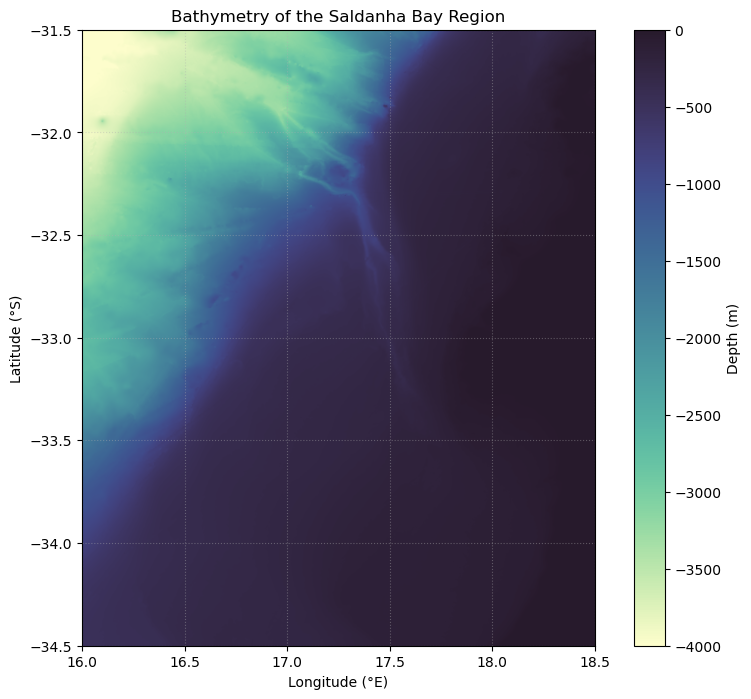

In [9]:

# Extract coordinate limits
x_min, x_max = bathy.x_range.values
y_min, y_max = bathy.y_range.values

# Plot bathymetry 
plt.figure(figsize=(10, 8))

plt.imshow(
    z,
    origin="lower",
    cmap=cmocean.cm.deep,
    vmin=-4000,
    vmax=0,
    extent=[x_min, x_max, y_min, y_max]  
)

# Add colorbar
plt.colorbar(label="Depth (m)")

# Add labels and title
plt.title("Bathymetry of the Saldanha Bay Region")
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°S)")
plt.grid(True, linestyle=":", alpha=0.4)

plt.savefig("bathymetry_saldanha.png", dpi=300, bbox_inches="tight")

plt.show()
